In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" DATA PREPROCESSING & FEATURE ENGINEERING")
print("="*70)

# Load datasets
print("\n Loading data...")
train = pd.read_csv(r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\Raw Data\train.csv")
features = pd.read_csv(r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\Raw Data\features.csv")

# Merge datasets
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

# Convert date to datetime
df['Date'] = pd.to_datetime(df['Date'])

print(f" Data loaded! Shape: {df.shape}")
print(f" Date range: {df['Date'].min()} to {df['Date'].max()}")

 DATA PREPROCESSING & FEATURE ENGINEERING

 Loading data...
 Data loaded! Shape: (421570, 14)
 Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00


In [2]:
print("\n Checking missing values...")
print(df.isnull().sum())

# Fill missing values with appropriate methods
print("\n Filling missing values...")

# For MarkDown columns (promotional markdowns)
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
for col in markdown_cols:
    if col in df.columns:
        df[col].fillna(0, inplace=True)  # No markdown = 0

# For CPI and Unemployment (forward fill for time series)
if 'CPI' in df.columns:
    df['CPI'].fillna(method='ffill', inplace=True)
if 'Unemployment' in df.columns:
    df['Unemployment'].fillna(method='ffill', inplace=True)

print(" Missing values handled!")
print("\nMissing values after cleaning:")
print(df.isnull().sum().sum(), "missing values remaining")


 Checking missing values...
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64

 Filling missing values...
 Missing values handled!

Missing values after cleaning:
0 missing values remaining


In [3]:
print("\n Creating time-based features...")

# Extract date components
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Quarter'] = df['Date'].dt.quarter
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['DayOfYear'] = df['Date'].dt.dayofyear

# Cyclical encoding for better model understanding
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['Week_sin'] = np.sin(2 * np.pi * df['Week'] / 52)
df['Week_cos'] = np.cos(2 * np.pi * df['Week'] / 52)

# Week of month
df['WeekOfMonth'] = (df['Day'] - 1) // 7 + 1

print("Time features created!")
print(f"New columns added: {['Year', 'Month', 'Week', 'Day', 'DayOfWeek', 'Quarter', 'IsWeekend', 'DayOfYear', 'WeekOfMonth']}")


 Creating time-based features...
Time features created!
New columns added: ['Year', 'Month', 'Week', 'Day', 'DayOfWeek', 'Quarter', 'IsWeekend', 'DayOfYear', 'WeekOfMonth']


In [4]:
print("\n⏮ Creating lag features (past sales information)...")

# Sort by Store, Dept, and Date
df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

# Create lag features for each Store-Dept combination
lag_periods = [1, 2, 3, 4, 8, 12]  # 1 week ago, 2 weeks ago, etc.

for lag in lag_periods:
    df[f'Sales_Lag_{lag}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)
    print(f"  Created lag {lag} weeks")

print(" Lag features created!")


⏮ Creating lag features (past sales information)...
  Created lag 1 weeks
  Created lag 2 weeks
  Created lag 3 weeks
  Created lag 4 weeks
  Created lag 8 weeks
  Created lag 12 weeks
 Lag features created!


In [5]:
print("\n Creating rolling window features (trends)...")

# Rolling statistics
windows = [4, 8, 12]  # 4, 8, 12 weeks

for window in windows:
    # Rolling mean
    df[f'Sales_RollingMean_{window}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    
    # Rolling std (volatility)
    df[f'Sales_RollingStd_{window}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )
    
    # Rolling min
    df[f'Sales_RollingMin_{window}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
        lambda x: x.rolling(window=window, min_periods=1).min()
    )
    
    # Rolling max
    df[f'Sales_RollingMax_{window}'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
        lambda x: x.rolling(window=window, min_periods=1).max()
    )
    
    print(f"  Created rolling features for {window} weeks")

print(" Rolling window features created!")


 Creating rolling window features (trends)...
  Created rolling features for 4 weeks
  Created rolling features for 8 weeks
  Created rolling features for 12 weeks
 Rolling window features created!


In [6]:
print("\n Creating statistical features...")

# Growth rate (compared to previous week)
df['Sales_Growth'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].pct_change()

# Difference from mean
df['Sales_DiffFromMean'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
    lambda x: x - x.mean()
)

# Sales ratio (current vs 4-week average)
df['Sales_Ratio_4w'] = df['Weekly_Sales'] / (df['Sales_RollingMean_4'] + 1)

print(" Statistical features created!")


 Creating statistical features...
 Statistical features created!


In [7]:
print("\n Creating holiday and special event features...")

# IsHoliday is already there, let's enhance it
df['IsHoliday'] = df['IsHoliday'].astype(int)

# Black Friday detection (day after Thanksgiving - 4th Thursday of November)
df['IsBlackFriday'] = 0
# Approximate Black Friday dates
black_friday_dates = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23'])
for bf_date in black_friday_dates:
    df.loc[df['Date'] == bf_date, 'IsBlackFriday'] = 1

# Christmas season (Dec 1 - Dec 31)
df['IsChristmasSeason'] = ((df['Month'] == 12)).astype(int)

# Back to school season (August)
df['IsBackToSchool'] = (df['Month'] == 8).astype(int)

# Summer season
df['IsSummer'] = (df['Month'].isin([6, 7, 8])).astype(int)

print(" Holiday and event features created!")


 Creating holiday and special event features...
 Holiday and event features created!


In [8]:
print("\n Detecting and handling outliers...")

# Calculate outliers using IQR method
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR  # Using 3 IQR (less aggressive)
upper_bound = Q3 + 3 * IQR

outliers_count = ((df['Weekly_Sales'] < lower_bound) | (df['Weekly_Sales'] > upper_bound)).sum()
print(f"   Found {outliers_count} outliers ({outliers_count/len(df)*100:.2f}%)")

# Cap outliers instead of removing them
df['Weekly_Sales'] = df['Weekly_Sales'].clip(lower=lower_bound, upper=upper_bound)

print(" Outliers handled!")


 Detecting and handling outliers...
   Found 12830 outliers (3.04%)
 Outliers handled!


In [9]:
print("\n Cleaning up NaN values created by feature engineering...")

print(f"Rows before: {len(df)}")
df_clean = df.dropna()
print(f"Rows after: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)} rows")

print("\nFinal shape:", df_clean.shape)
print("Total features:", len(df_clean.columns))


 Cleaning up NaN values created by feature engineering...
Rows before: 421570
Rows after: 382954
Removed: 38616 rows

Final shape: (382954, 52)
Total features: 52


In [11]:
print("\n Saving processed data...")

# Save to CSV
df_clean.to_csv(r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\Processed data/processed_walmart_sales.csv", index=False)

print(" Processed data saved!")
print(r"C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\Processed data/processed_walmart_sales.csv")

# Display feature summary
print("\n FEATURE ENGINEERING SUMMARY:")
print("="*70)
print(f"Original features: ~10")
print(f"Total features now: {len(df_clean.columns)}")
print(f"Features added: ~{len(df_clean.columns) - 10}")

print("\n Feature categories created:")
print("   • Time-based features (Year, Month, Week, etc.)")
print("   • Lag features (past 1, 2, 3, 4, 8, 12 weeks)")
print("   • Rolling statistics (mean, std, min, max)")
print("   • Statistical features (growth, ratios)")
print("   • Holiday and event features")
print("   • Cyclical encodings (sin/cos transformations)")

print("\n" + "="*70)
print(" DATA PREPROCESSING COMPLETE!")
print("="*70)
print("\n Dataset is now ready for machine learning models!")


 Saving processed data...
 Processed data saved!
C:\Users\daraa\Desktop\AI_Sales_Forecasting\Data\Processed data/processed_walmart_sales.csv

 FEATURE ENGINEERING SUMMARY:
Original features: ~10
Total features now: 52
Features added: ~42

 Feature categories created:
   • Time-based features (Year, Month, Week, etc.)
   • Lag features (past 1, 2, 3, 4, 8, 12 weeks)
   • Rolling statistics (mean, std, min, max)
   • Statistical features (growth, ratios)
   • Holiday and event features
   • Cyclical encodings (sin/cos transformations)

 DATA PREPROCESSING COMPLETE!

 Dataset is now ready for machine learning models!


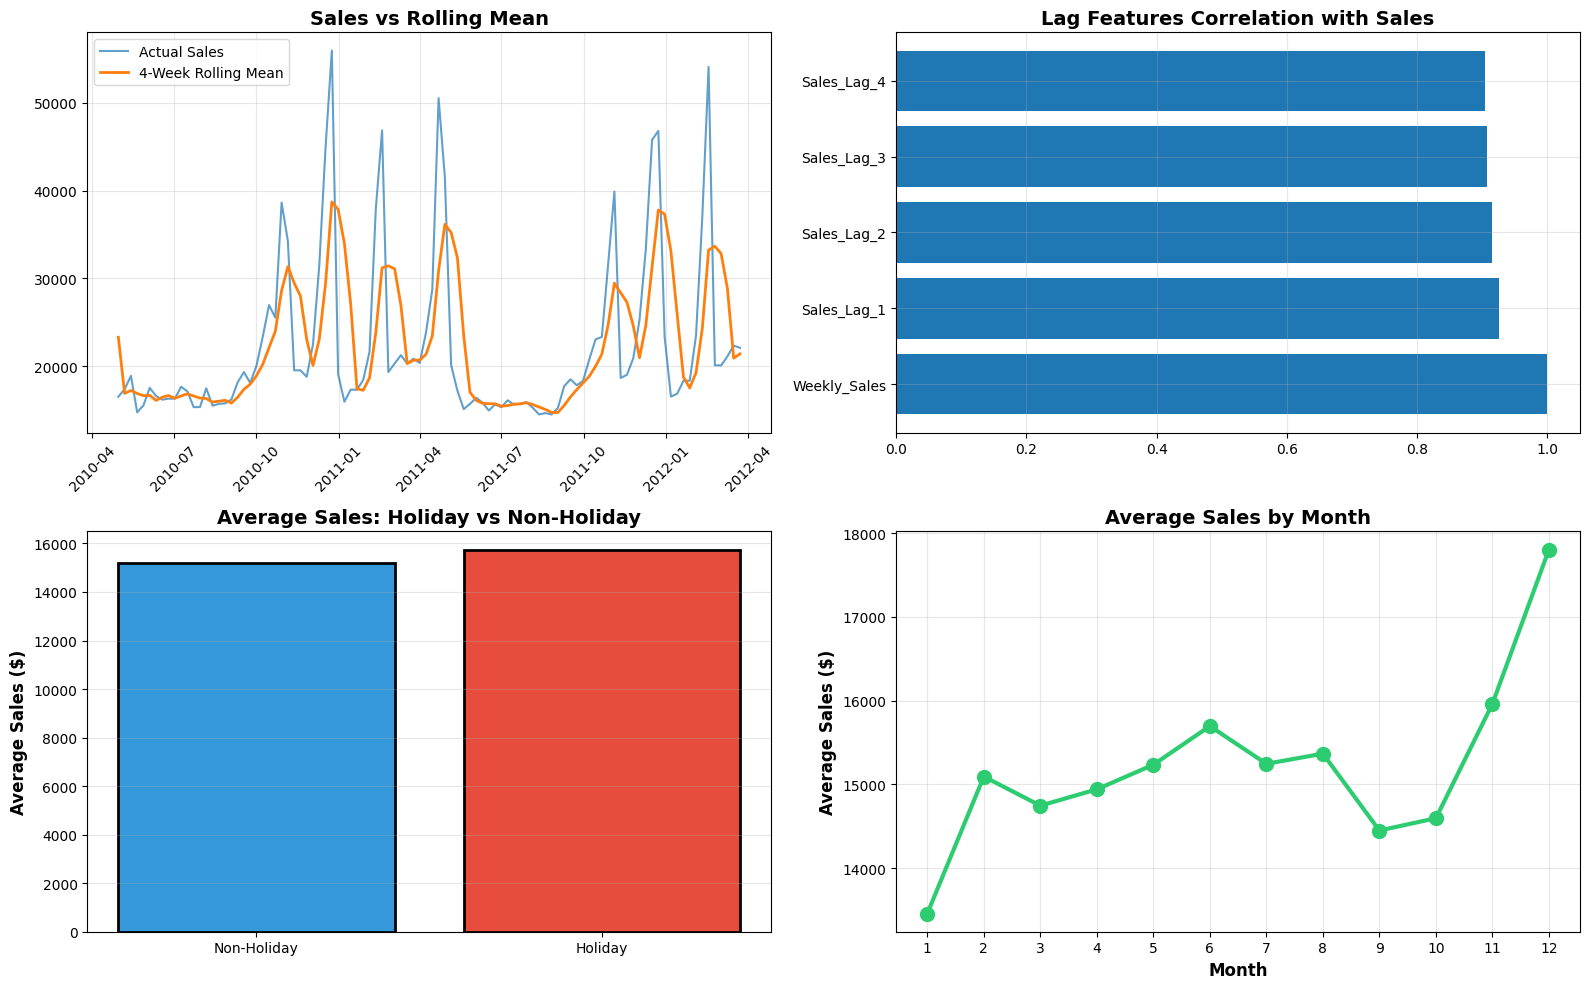

 Visualization saved: results/07_feature_engineering_summary.png


In [12]:
# Visualize some new features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Sales with rolling mean
sample_data = df_clean[(df_clean['Store'] == 1) & (df_clean['Dept'] == 1)].head(100)
axes[0, 0].plot(sample_data['Date'], sample_data['Weekly_Sales'], label='Actual Sales', alpha=0.7)
axes[0, 0].plot(sample_data['Date'], sample_data['Sales_RollingMean_4'], 
                label='4-Week Rolling Mean', linewidth=2)
axes[0, 0].set_title('Sales vs Rolling Mean', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Lag features correlation
lag_cols = ['Weekly_Sales'] + [col for col in df_clean.columns if 'Lag' in col][:4]
lag_corr = df_clean[lag_cols].corr()['Weekly_Sales'].sort_values(ascending=False)
axes[0, 1].barh(range(len(lag_corr)), lag_corr.values)
axes[0, 1].set_yticks(range(len(lag_corr)))
axes[0, 1].set_yticklabels(lag_corr.index)
axes[0, 1].set_title('Lag Features Correlation with Sales', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Holiday impact
holiday_comparison = df_clean.groupby('IsHoliday')['Weekly_Sales'].mean()
axes[1, 0].bar(['Non-Holiday', 'Holiday'], holiday_comparison.values, 
               color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=2)
axes[1, 0].set_title('Average Sales: Holiday vs Non-Holiday', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Average Sales ($)', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Monthly pattern
monthly_avg = df_clean.groupby('Month')['Weekly_Sales'].mean()
axes[1, 1].plot(monthly_avg.index, monthly_avg.values, marker='o', 
                markersize=10, linewidth=3, color='#2ecc71')
axes[1, 1].set_title('Average Sales by Month', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Average Sales ($)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/daraa/Desktop/AI_Sales_Forecasting/Results/07_feature_engineering_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualization saved: results/07_feature_engineering_summary.png")